<a href="https://colab.research.google.com/github/jezekvi/Spatial-Data-Science-with-Python/blob/main/5_cloud_native/time_series_fire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalace a import
!pip install -q pystac-client stackstac planetary-computer rioxarray

import pystac_client
import planetary_computer as pc
import stackstac
import geopandas as gpd
import pandas as pd
import rioxarray
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.4 MB/s eta 0:00:00


In [2]:
# Nacteni shapefile

path = "/content/burned_area_DECZ.shp"
aoi = gpd.read_file(path).to_crs(epsg=4326)
bbox = aoi.total_bounds

print(bbox)

[14.23796086 50.8616173  14.35559177 50.9132275 ]


In [10]:
# Inicializace STAC

catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# S2 L2A
search = catalog.search(
    collections = ["sentinel-2-l2a"],
    bbox = bbox,
    datetime = "2022-05-01/2022-10-31",
    query = {"sat:relative_orbit": {"eq": 22}}
)

items = search.item_collection()
signed_items = pc.sign(items)

print(len(signed_items))


65


In [11]:
# Tvorba DataCube

cube = stackstac.stack(
    signed_items,
    assets = ["B04", "B08", "SCL"],
    bounds_latlon = bbox,
    epsg = 32633,
    resolution = 10
)

In [12]:
# Harmonizace S2

red = (cube.sel(band="B04") -1000) / 10000
nir = (cube.sel(band="B08") -1000) / 10000
scl = (cube.sel(band="SCL"))

In [13]:
# Clip

aoi_utm = aoi.to_crs(cube.crs)

red_clip = red.rio.clip(aoi_utm.geometry, aoi_utm.crs)
nir_clip = nir.rio.clip(aoi_utm.geometry, aoi_utm.crs)
scl_clip = scl.rio.clip(aoi_utm.geometry, aoi_utm.crs)

In [14]:
# Maskovani

clouds = [3, 8, 9, 10]

valid_mask = ~scl_clip.isin(clouds)

In [15]:
# Vypocet NDVI

ndvi = (nir_clip - red_clip) / (nir_clip + red_clip)
ndvi_masked = ndvi.where(valid_mask)

print(ndvi_masked)

<xarray.DataArray 'stackstac-37784effbb6179a24a3ab32fd08dff9a' (time: 65,
                                                                y: 578, x: 830)> Size: 249MB
dask.array<where, shape=(65, 578, 830), dtype=float64, chunksize=(1, 578, 830), chunktype=numpy.ndarray>
Coordinates: (12/44)
  * time                                     (time) datetime64[ns] 520B 2022-...
    id                                       (time) <U54 14kB 'S2B_MSIL2A_202...
    platform                                 (time) <U11 3kB 'Sentinel-2B' .....
    s2:not_vegetated_percentage              (time) float64 520B 6.457 ... 20.31
    s2:vegetation_percentage                 (time) float64 520B 26.86 ... 39.94
    s2:saturated_defective_pixel_percentage  (time) float64 520B 0.0 0.0 ... 0.0
    ...                                       ...
    spatial_ref                              int64 8B 0
    band                                     <U3 12B 'SCL'
    title                                    <U29 116B '

In [16]:
# Median za celou oblast

ndvi_series = ndvi_masked.median(dim=["x", "y"]).compute()

# Filtrace (alespon 80)
valid_ratio = valid_mask.mean(dim=["x", "y"]).compute()
ndvi_filtered = ndvi_series.where(valid_ratio > 0.8, drop=True)



/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1233: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [17]:
# Kontrola filtrace
print(f"pred: {len(ndvi_series)}")
print(f"po: {len(ndvi_filtered)}")

print(ndvi_filtered)

pred: 65
po: 28
<xarray.DataArray 'stackstac-37784effbb6179a24a3ab32fd08dff9a' (time: 28)> Size: 224B
array([0.47295992, 0.607078  , 0.60447382, 0.66269165, 0.70416298,
       0.70454604, 0.70540052, 0.70528159, 0.72992056, 0.72930166,
       0.68462101, 0.63625341, 0.63500331, 0.71194539, 0.70743553,
       0.27232143, 0.36487812, 0.3655914 , 0.28595655, 0.35089986,
       0.35015291, 0.30933235, 0.30989704, 0.37076147, 0.3691086 ,
       0.41176471, 0.4122807 , 0.32885906])
Coordinates: (12/43)
  * time                                     (time) datetime64[ns] 224B 2022-...
    id                                       (time) <U54 6kB 'S2B_MSIL2A_2022...
    platform                                 (time) <U11 1kB 'Sentinel-2B' .....
    s2:not_vegetated_percentage              (time) float64 224B 6.457 ... 20.31
    s2:vegetation_percentage                 (time) float64 224B 26.86 ... 39.94
    s2:saturated_defective_pixel_percentage  (time) float64 224B 0.0 0.0 ... 0.0
    ...     

/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


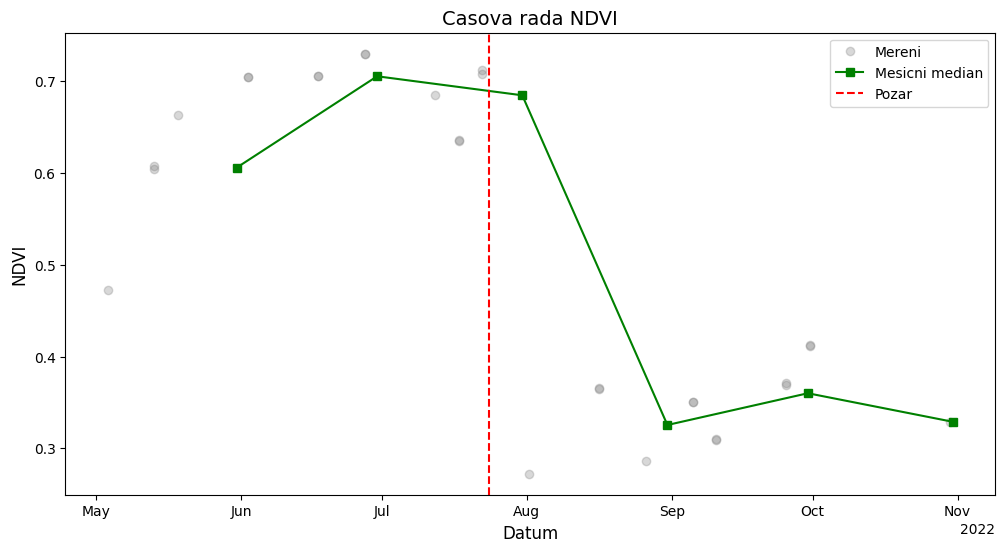

In [18]:
# Graf casove rady NDVI

# Mesicni median
monthly = ndvi_filtered.resample(time='1M').median()

# Graf
plt.figure(figsize=(12, 6))

# Puvodni mereni
plt.plot(ndvi_filtered.time, ndvi_filtered, 'o', color='gray', alpha=0.3, label='Mereni')

# Mesicni trend
monthly.plot(marker='s', color='green', label='Mesicni median')

# Cervena cara pozar
plt.axvline(pd.to_datetime("2022-07-24"), color='red', linestyle='--', label='Pozar')

#Popisky
plt.title("Casova rada NDVI", fontsize=14)
plt.xlabel("Datum", fontsize=12)
plt.ylabel("NDVI", fontsize=12)

plt.legend()
plt.show()